# Интро

In [87]:
import math
import shap
import optuna
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
# from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE, RandomOverSampler
from sklearn.metrics import roc_curve, recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report, roc_auc_score

In [2]:
df = pd.read_csv('data.xls')

Датасет содержит:
- информацию о клиентах, которые ушли в течение последнего месяца – столбец называется 'Churn'
- информацию о услугах, которыми пользовался клиент: 
    - Подключена ли телефонная связь (PhoneService)
    - Использует ли клиент несколько телефонных линий (MultipleLines)
    - Тип интернет-подключения клиента(InternetService)
    - Подключена ли услуга интернет-безопасности (OnlineSecurity)
    - Подключено ли облачное резервное копирование данных (OnlineBackup) 
    - Подключена ли услуга гарантии на устройства (DeviceProtection)
    - Подключена ли техническая поддержка (TechSupport)
    - Подключено ли телевидение (StreamingTV)
    - Подключены ли фильмы (StreamingMovies)
- информацию о договоре с клиентом
    - Продолжительность обслуживания клиента (в месяцах) (tenure)
    - Тип договора с клиентом (Contract)
    - Способ оплаты (PaymentMethod)
    - Электронные счета (PaperlessBilling)
    - Ежемесячная стоимость услуг (MonthlyCharges)
    - Общая сумма платежей (TotalCharges)
- демографическую информацию о клиентах 
    - пол (gender) 
    - является ли клиент пенсионером (SeniorCitizen)
    - наличие партнеров (Partner)
    - наличие иждивенцев (Dependents)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# предобработка данных 

удаление колонки с индексами

In [5]:
df = df.drop(columns='customerID')

колонка 'TotalCharges' содержит числовые данные, но тип у нее текстовый, исправим это 

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

в колонке 'TotalCharges' оказывается 11 пропусков  
если посмотреть клиентов с пропусками то у них будет проставлен ежемесячный счет, но у всех будет срок обслуживания ('tenure') равен нулю

In [7]:
print('количество пропусков:',df['TotalCharges'].isna().sum())

df[df['TotalCharges'].isna()].head(11)

количество пропусков: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


если взглянуть на всех клиентов со сроком обслуживания = 0  
то выходит, что это тот же список клиентов и новых клиентов с нулевым сроком обслуживания не прибавилось 

In [8]:
df[df['tenure']==0].head(11)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Удаляю эти значения

In [9]:
df = df.dropna()

In [10]:
df.isna().sum().sum()

np.int64(0)

проверка на дубликаты  
в датасете 22 дубликата их тоже удаляю

In [11]:
df[df.duplicated()].shape

(22, 20)

In [12]:
df = df.drop_duplicates()

# Визуализация

В датасете количество клиентов разных полов одинаково,  
а количество ушедших клиентов составляет около четверти от всего количества клиентов в датасете

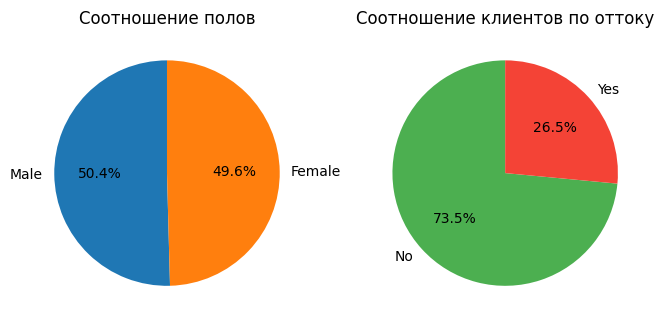

In [13]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(8, 4))

x = df['gender'].value_counts().index
y = df['gender'].value_counts().values
ax[0].pie(y, labels=x, autopct='%1.1f%%', startangle=90)
ax[0].set_title('Соотношение полов')

x = df['Churn'].value_counts().index
y = df['Churn'].value_counts().values
ax[1].pie(y, labels=x, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#F44336'])
ax[1].set_title('Соотношение клиентов по оттоку')
plt.show()

Соотношения ушедших/оставшихся клиентов относительно пола примерно равны  
Значит представители обоих полов ведут себя схожим образом при решении о смене компании

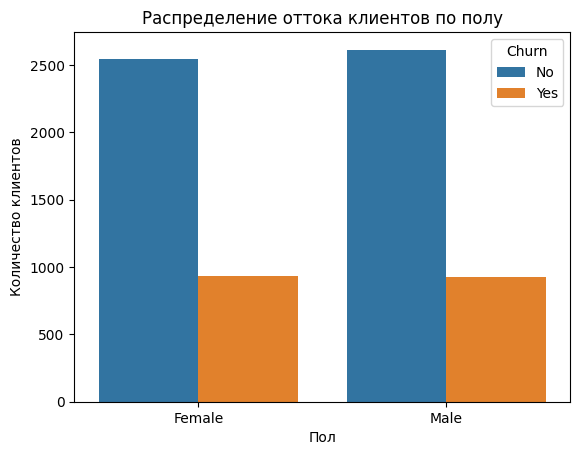

In [14]:
sns.countplot(data=df, x='gender', hue='Churn')
plt.title('Распределение оттока клиентов по полу')
plt.xlabel('Пол')
plt.ylabel('Количество клиентов')
plt.show()

Соотношение внутри категорий контрактов для мужчин и женщин одинаковы  
А вот распределения типов контрактов среди ушедших и оставшихся клиентов отличаются  
Можно сказать, что наибольшая доля клиентов, прекративших пользоваться услугами компании, приходится на пользователей с помесячным контрактом (Month-to-month)

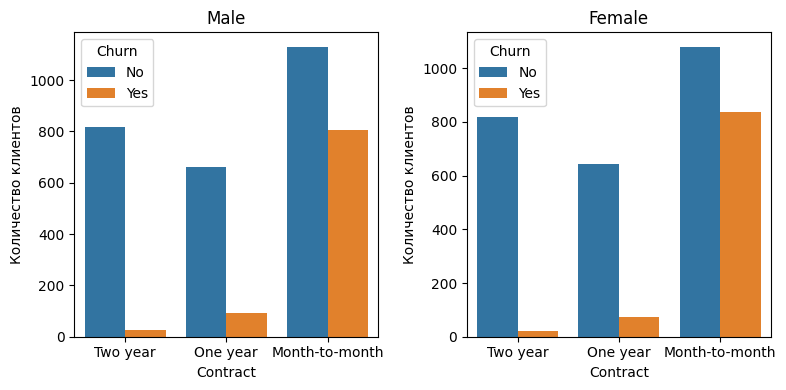

In [15]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(8, 4))

x_col = 'Contract'
x_order = sorted(df[x_col].unique(), reverse=True)

data = df[df['gender']=='Male']
sns.countplot(data=data, x=x_col, hue='Churn', ax=ax[0], hue_order=['No', 'Yes'], order=x_order)
ax[0].set_xlabel(x_col)
ax[0].set_ylabel('Количество клиентов')
ax[0].set_title('Male')

data = df[df['gender']=='Female']
sns.countplot(data=data, x=x_col, hue='Churn', ax=ax[1], hue_order=['No', 'Yes'], order=x_order)
ax[1].set_xlabel(x_col)
ax[1].set_ylabel('Количество клиентов')
ax[1].set_title('Female')
plt.tight_layout()
plt.show()

Далее соотношение полов во всех категориях будет одинаковым, поэтому привожу графики без разделения по полу

Ниже приведены соотношения между ушедшими и оставшимися клиентами по всем категориальным признакам  
Самое главное из граифков, к уходу от компании более склонны клиенты:  
- без партнера  
- без детей
- с подключенной телефонной связью
- на оптоволкне
- без услуг интернет-безопасности, облачных сохраннеий, гаранитии на устройства, тех.поддержки
- с помесячным контрактом
- без бумажных чеков 
- использующие электронными счета 


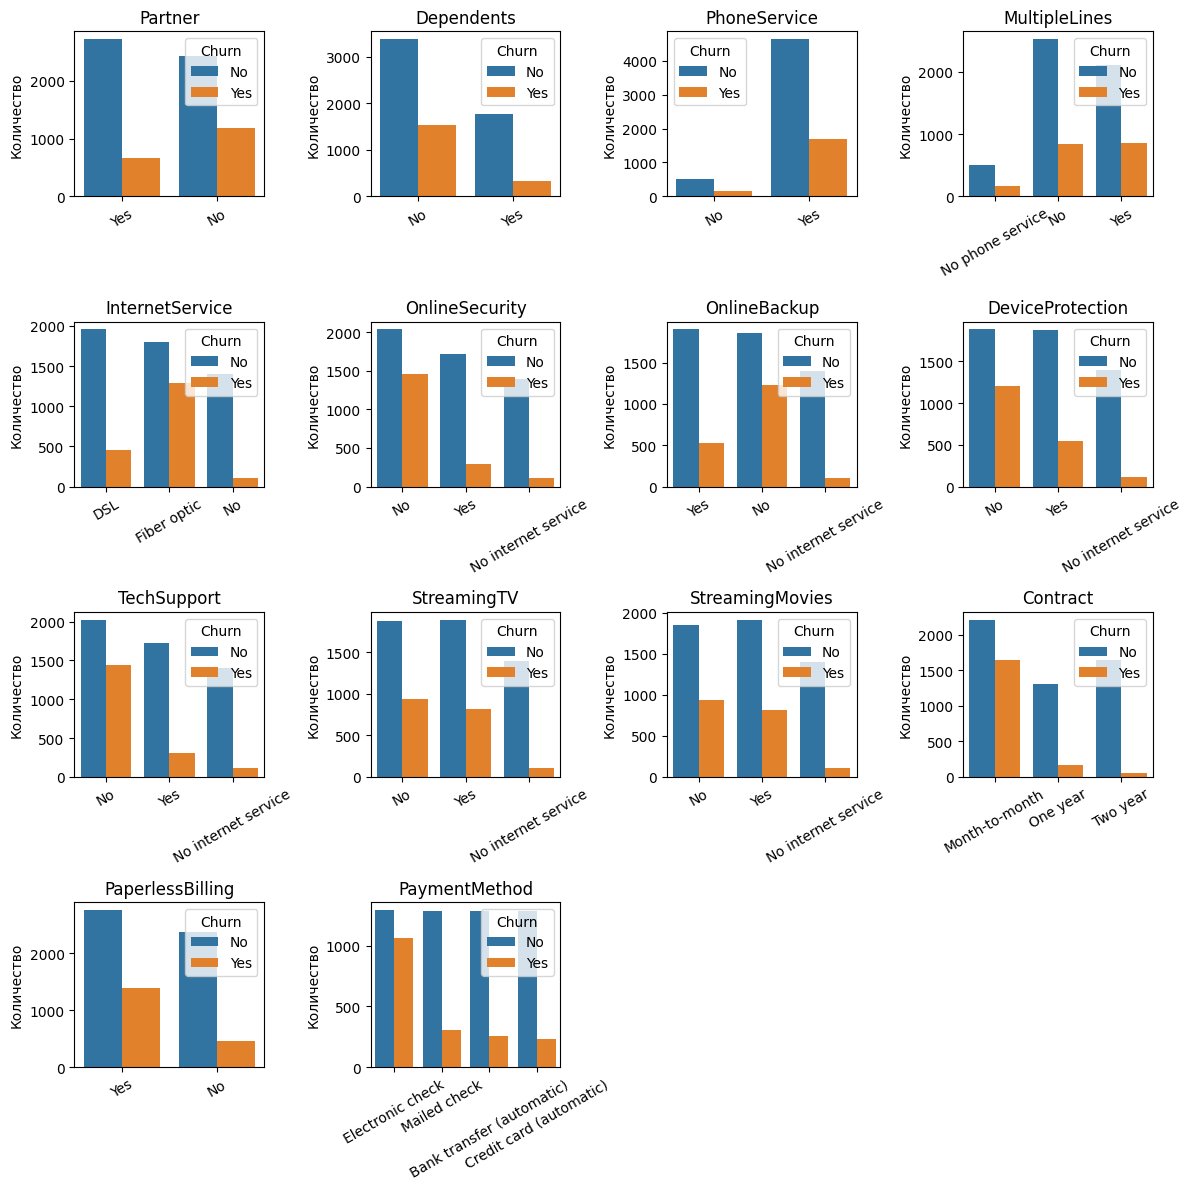

In [16]:
cat_cols = df.select_dtypes(include='str').columns.drop(['gender', 'Churn'])

n_cols = 4
n_rows = math.ceil(len(cat_cols) / n_cols)
fig = plt.figure(figsize=(12, 12))

for i, col in enumerate(cat_cols, start=1):
    ax = fig.add_subplot(n_rows, n_cols, i)
    sns.countplot(data=df, x=col, hue='Churn', hue_order=['No', 'Yes'], ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Количество')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Клиенты с более высокими ежемесячными платежами более склонны к уходу от компании

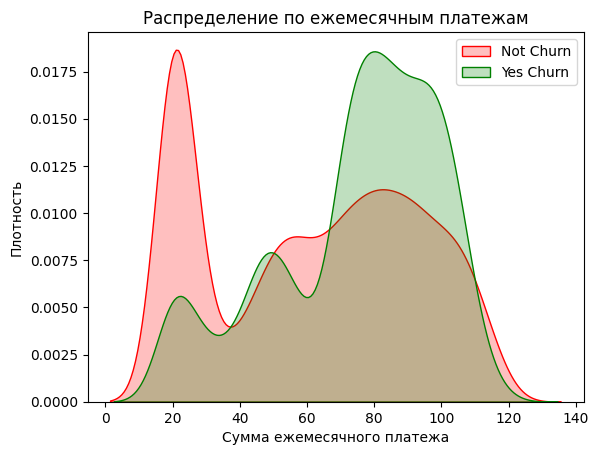

In [17]:
sns.kdeplot(df['MonthlyCharges'][df['Churn'] == 'No'], color='r', fill=True, label='Not Churn')
sns.kdeplot(df['MonthlyCharges'][df['Churn'] == 'Yes'], color='g', fill=True, label='Yes Churn')
plt.legend()
plt.ylabel('Плотность')
plt.xlabel('Сумма ежемесячного платежа')
plt.title('Распределение по ежемесячным платежам')
plt.show()

Большая часть уходящих клиентов имеет сравнительно небольшие суммы платежей за все время

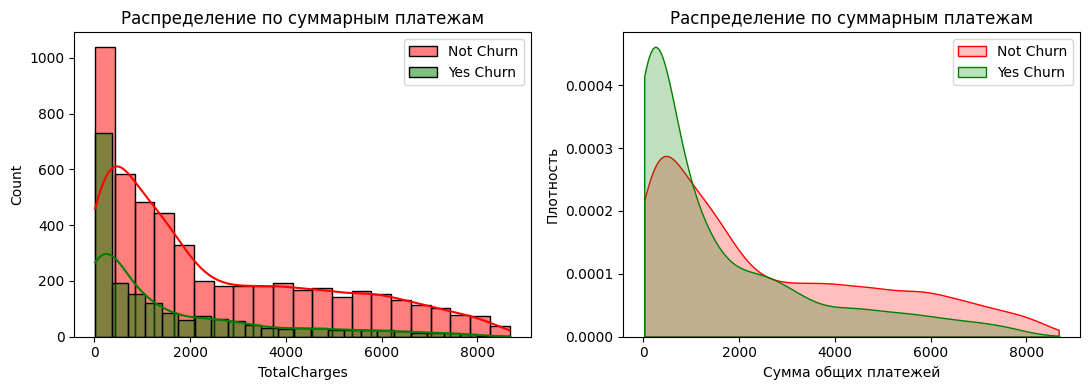

In [18]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(11, 4))

x_col = 'Contract'
x_order = sorted(df[x_col].unique(), reverse=True)

sns.histplot(df['TotalCharges'][df['Churn'] == 'No'], kde=True, color='r', label='Not Churn', ax=ax[0])
sns.histplot(df['TotalCharges'][df['Churn'] == 'Yes'], kde=True, color='g', label='Yes Churn', ax=ax[0])
ax[0].set_title('Распределение по суммарным платежам')
ax[0].legend()

sns.kdeplot(df['TotalCharges'][df['Churn'] == 'No'], cut=0, color='r', fill=True, label='Not Churn', ax=ax[1])
sns.kdeplot(df['TotalCharges'][df['Churn'] == 'Yes'], cut=0, color='g', fill=True, label='Yes Churn', ax=ax[1])
ax[1].set_xlabel('Сумма общих платежей')
ax[1].set_ylabel('Плотность')
ax[1].set_title('Распределение по суммарным платежам')
ax[1].legend()
plt.tight_layout()
plt.show()

In [19]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


Клиенты, прекратившие пользоваться услугами компании, как правило, имеют меньший срок обслуживания, чем оставшиеся клиенты.  
Можно предположить, что вероятность оттока наиболее высока в первые месяцы после подключения услуг

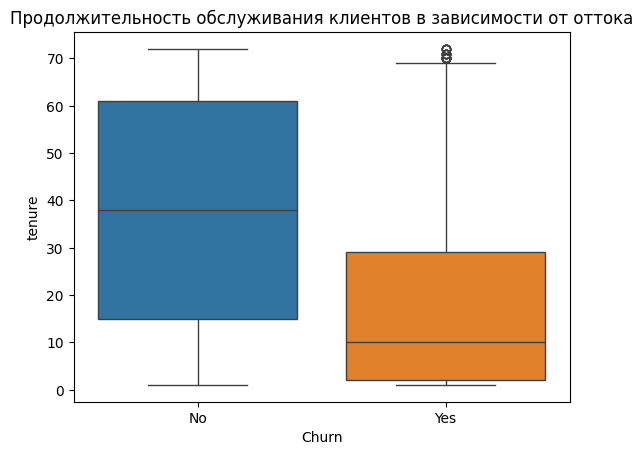

In [20]:
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn')
plt.title('Продолжительность обслуживания клиентов в зависимости от оттока')
plt.show()

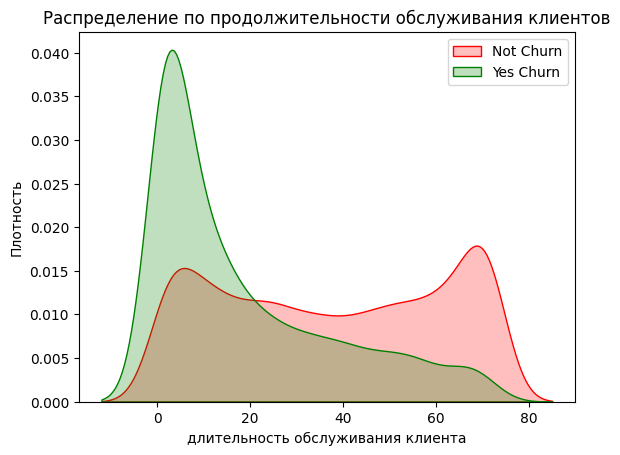

In [21]:
sns.kdeplot(df['tenure'][df['Churn'] == 'No'], color='r', fill=True, label='Not Churn')
sns.kdeplot(df['tenure'][df['Churn'] == 'Yes'], color='g', fill=True, label='Yes Churn')
plt.legend()
plt.ylabel('Плотность')
plt.xlabel('длительность обслуживания клиента')
plt.title('Распределение по продолжительности обслуживания клиентов')
plt.show()

# feature engineering

In [22]:
df = pd.read_csv('data.xls')

df = df.drop(columns='customerID')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

отделение целевой переменной

In [23]:
target = df['Churn']
df = df.drop(columns='Churn')

target = target.replace({'Yes':1, 'No':0}).astype(int)

In [24]:
df_c = df.copy()

В наборе данных присутствует ряд категориальных признаков  
Для каждого из них ниже приведены возможные значения:  
<u>'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'</u> - ['Yes', 'No']  
<u>'MultipleLines'</u>  - ['No phone service', 'No', 'Yes']  
<u>'InternetService'</u>  - ['DSL', 'Fiber optic', 'No']  
<u>'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'StreamingTV','TechSupport', 'StreamingMovies'</u>  - ['No', 'Yes', 'No internet service']  
<u>'Contract'</u>  - ['Month-to-month', 'One year', 'Two year']  
<u>'PaymentMethod'</u>  - ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']  



Представленные признаки являются категориальными и содержат текстовые значения  
поэтому перед обучением моделей машинного обучения они требуют преобразования в числовой формат  

Бинарные признаки gender, Partner, Dependents, PhoneService и PaperlessBilling были закодированы значениями 0 и 1  

Для признаков InternetService, Contract и PaymentMethod, имеющих более двух категорий, применено One-Hot-кодирование

Признак MultipleLines также был преобразован в бинарный формат (0, 1), при этом значение 'No phone service' было объединено с категорией 'No', так как полное остутствуе телефона уже зашито в 'PhoneService'

Для группы признаков, характеризующих интернет-услуги (OnlineSecurity, OnlineBackup, DeviceProtection, StreamingTV, TechSupport, StreamingMovies), значения 'No internet service' были заменены на 0, а Yes и No — на 1 и 0 соответственно  
Дополнительно был сформирован признак have_internet_serv, отражающий наличие у клиента подключения к интернету

Так же были сгенеирированы новые признаки:
- общее количество подключенных интернет-услуг (internet_sum)
- бинарный признак наличия полного набора услуг связанных с интернетом (full_internet)
- бинарный признак использования хотя бы одного потокового сервиса (full_streaming)
- общее количество подключенных услуг (all_services)
- средняя стоимость одной подключенной услуги (bill_per_service)
- средний ежемесячный платеж за весь период обслуживания (avg_bill_per_month)
- разница между текущим ежемесячным платежом и средним платежом (bill_diff)
- логарифмированное значение (tenure_log)
- квадрат признака (tenure_sq)
- длительность обслуживания была разбита на интервалы (0–3, 3–6, 6–12, 12–24 и 24–72 месяцев) Hot-кодирована

In [25]:
df['gender'] = df['gender'].replace({'Male':1, 'Female':0}).astype(int)

categ_2 = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
df[categ_2] = df[categ_2].replace({'Yes':1, 'No':0}).astype(int)

categ_compl = ['InternetService', 'Contract', 'PaymentMethod']
df_dum = pd.get_dummies(df[categ_compl], dtype=int)
df = df.drop(columns=categ_compl)
df = pd.concat((df, df_dum), axis=1)

df['MultipleLines'] = df['MultipleLines'].replace({'Yes':1, 'No':0, 'No phone service':0}).astype(int)

categ_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'StreamingTV','TechSupport', 'StreamingMovies']
df['have_internet_serv'] = (df['OnlineSecurity'] != 'No internet service').astype(int)
df[categ_internet] = df[categ_internet].replace({'Yes':1, 'No':0, 'No internet service':0}).astype(int)

#new
df['internet_sum'] = df[categ_internet].sum(axis=1)
df['full_internet'] = ((df['OnlineSecurity'] == 1) & (df['OnlineBackup'] == 1) & (df['DeviceProtection'] == 1)).astype(int)
df['full_streaming'] = ((df['StreamingTV'] == 1) | (df['StreamingMovies'] == 1)).astype(int)
df['all_sevices'] = df['PhoneService'] + df['MultipleLines'] + df['internet_sum']
df['bil_per_service'] = df['MonthlyCharges'] / (df['all_sevices'].replace(0, 1))
df['avg_bill_per_month'] = df['TotalCharges'] / df['tenure']
df['bill_diff'] = df['MonthlyCharges'] - df['avg_bill_per_month']
df['tenure_log'] = np.log1p(df['tenure'])
df['tenure_sq'] = df['tenure'] ** 2

tenure_groups = pd.cut(df['tenure'], bins=[0, 3, 6, 12, 24, 72], labels=['0-3', '3-6', '6-12', '12-24', '24-72'])
tenure_hot_groups = pd.get_dummies(tenure_groups, dtype=int)
df = pd.concat((df, tenure_hot_groups), axis=1)


In [26]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'bil_per_service', 'avg_bill_per_month', 'bill_diff', 'tenure_log', 'tenure_sq', 'internet_sum', 'all_sevices']

В тесте Шапиро-Уилка нулевая гипотеза:
H0: Данные распределены нормально

Согласно значению p, полученному в результате теста Шапиро (p < 5%), мы отвергаем нашу нулевую гипотезу (H0)  
Таким образом, все числовые поля не принадлежат к нормальному распределению.

In [27]:
for i in range(len(num_cols)):
    stat,p = shapiro(df[num_cols[i]])
    print(num_cols[i])
    print('P_value=%.2f' % (p))
    print()

tenure
P_value=0.00

MonthlyCharges
P_value=0.00

TotalCharges
P_value=0.00

bil_per_service
P_value=0.00

avg_bill_per_month
P_value=0.00

bill_diff
P_value=0.00

tenure_log
P_value=0.00

tenure_sq
P_value=0.00

internet_sum
P_value=0.00

all_sevices
P_value=0.00



c:\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7032.
  res = hypotest_fun_out(*samples, **kwds)


In [28]:
corr = pd.concat((df, target), axis=1).corr()
corr['Churn'].sort_values(ascending=False)

# plt.figure(figsize=(25, 10))
# mask = np.triu(np.ones_like(corr, dtype=bool))
# ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

Churn                                      1.000000
Contract_Month-to-month                    0.404565
bil_per_service                            0.312505
InternetService_Fiber optic                0.307463
PaymentMethod_Electronic check             0.301455
0-3                                        0.286812
have_internet_serv                         0.227578
MonthlyCharges                             0.192858
avg_bill_per_month                         0.192033
PaperlessBilling                           0.191454
SeniorCitizen                              0.150541
3-6                                        0.102860
full_streaming                             0.085040
6-12                                       0.070336
StreamingTV                                0.063254
StreamingMovies                            0.060860
MultipleLines                              0.040033
12-24                                      0.019929
PhoneService                               0.011691
bill_diff   

# ML predictions

baseline на датасете без предобработки

In [29]:
cat_features = df_c.select_dtypes(include=['str']).columns.tolist()
df_dummy = pd.get_dummies(df_c, prefix=['Contract', 'PaymentMethod'],columns=['Contract', 'PaymentMethod'], drop_first=True, dtype=int)
cat_features.remove('Contract')
cat_features.remove('PaymentMethod')
le = LabelEncoder() 
df_dummy[cat_features] = df_dummy[cat_features].apply(lambda col: le.fit_transform(col)) 

X_train, X_test, y_train, y_test = train_test_split(df_dummy, target, test_size=0.3, random_state=1, stratify=target)
col = X_train.columns
scaler = StandardScaler()

X_train[col] = scaler.fit_transform(X_train[col])
X_test[col] = scaler.transform(X_test[col])

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred= lr_model.predict(X_test)
f1 = f1_score(y_test, lr_pred)
print(f'Logistic Regression f1 score : {f1:.02}')
print(classification_report(y_test, lr_pred))

Logistic Regression f1 score : 0.61
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.66      0.57      0.61       561

    accuracy                           0.81      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



Main

In [30]:
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.3, random_state=1, stratify=target)

In [31]:
col = X_train.columns

In [32]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

исправление дисбаланса классов

In [33]:
randOverSample = RandomOverSampler(random_state=1)
X_train_1, y_train_1 = randOverSample.fit_resample(X_train, y_train)

smote = SMOTE(random_state=1)
X_train_2, y_train_2 = smote.fit_resample(X_train, y_train)

borderlinesmote = BorderlineSMOTE(random_state=1)
X_train_3, y_train_3 = borderlinesmote.fit_resample(X_train, y_train)

svmsmote = SVMSMOTE(random_state=1)
X_train_4, y_train_4 = svmsmote.fit_resample(X_train, y_train)

adasyn = ADASYN(random_state=1)
X_train_5, y_train_5 = adasyn.fit_resample(X_train, y_train)

print(f'До - 1: {sum(y_train==1)}, 0:{sum(y_train==0)}')
print(f'После - 1: {sum(y_train_1==1)}, 0:{sum(y_train_1==0)}')

До - 1: 1308, 0:3614
После - 1: 3614, 0:3614


Логистическая регрессия

Поскольку все рассмотренные методы устранения дисбаланса классов продемонстрировали одинаковое значение F1-меры,  
в дальнейшем для проведения экспериментов будет использоваться только метод SMOTE

In [34]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred= lr_model.predict(X_test)
f1_0 = f1_score(y_test, lr_pred)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_1, y_train_1)
lr_pred= lr_model.predict(X_test)
f1_1 = f1_score(y_test, lr_pred)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_2, y_train_2)
lr_pred= lr_model.predict(X_test)
f1_2 = f1_score(y_test, lr_pred)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_3, y_train_3)
lr_pred= lr_model.predict(X_test)
f1_3 = f1_score(y_test, lr_pred)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_4, y_train_4)
lr_pred= lr_model.predict(X_test)
f1_4 = f1_score(y_test, lr_pred)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_5, y_train_5)
lr_pred= lr_model.predict(X_test)
f1_5 = f1_score(y_test, lr_pred)

lr_res = [f1_0, f1_1, f1_2, f1_3, f1_4, f1_5]
for en, i in enumerate(lr_res):
    print(f'Logistic Regression {en} f1 score : {i:.02}')
    # print(classification_report(y_test, lr_pred))

Logistic Regression 0 f1 score : 0.6
Logistic Regression 1 f1 score : 0.63
Logistic Regression 2 f1 score : 0.63
Logistic Regression 3 f1 score : 0.63
Logistic Regression 4 f1 score : 0.63
Logistic Regression 5 f1 score : 0.63


метод опорных векторов

In [35]:
svm_model = SVC(random_state=1)
svm_model.fit(X_train_2, y_train_2)
svm_pred = svm_model.predict(X_test)
f1_svc = f1_score(y_test, svm_pred)
print(f'SVM f1 score: {f1_svc:.02}')
print(classification_report(y_test, svm_pred))

SVM f1 score: 0.62
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1549
           1       0.56      0.70      0.62       561

    accuracy                           0.78      2110
   macro avg       0.72      0.75      0.73      2110
weighted avg       0.80      0.78      0.78      2110



Случайный лес

In [ ]:
model_rf = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=50, max_leaf_nodes=30)
model_rf.fit(X_train_2, y_train_2)
pred_rf = model_rf.predict(X_test)
f1_rf = f1_score(y_test, pred_rf)
print(f'Random Forest f1 score: {f1_rf:.02}')
print(classification_report(y_test, pred_rf))

Random Forest f1 score: 0.62
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1549
           1       0.53      0.78      0.63       561

    accuracy                           0.76      2110
   macro avg       0.72      0.76      0.72      2110
weighted avg       0.80      0.76      0.77      2110



Бустинги

In [37]:
model_xgb = XGBClassifier(n_estimators=500, random_state=1)
model_xgb.fit(X_train_2, y_train_2)
pred_xgb = model_xgb.predict(X_test)
f1_xgb = f1_score(y_test, pred_xgb)
print(f'Random Forest f1 score: {f1_xgb:.02}')
print(classification_report(y_test, pred_xgb))

Random Forest f1 score: 0.55
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1549
           1       0.55      0.54      0.55       561

    accuracy                           0.76      2110
   macro avg       0.69      0.69      0.69      2110
weighted avg       0.76      0.76      0.76      2110



In [38]:
model_lgbm = LGBMClassifier(n_estimators=500, random_state=1, verbose=-1)
model_lgbm.fit(X_train_2, y_train_2)
pred_lgbm = model_lgbm.predict(X_test)
f1_lgbm = f1_score(y_test, pred_lgbm)
print(f'Random Forest f1 score: {f1_lgbm:.02}')
print(classification_report(y_test, pred_lgbm))

Random Forest f1 score: 0.56
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1549
           1       0.56      0.57      0.56       561

    accuracy                           0.77      2110
   macro avg       0.70      0.70      0.70      2110
weighted avg       0.77      0.77      0.77      2110



In [39]:
model_cat = CatBoostClassifier(n_estimators=1000, random_state=1, verbose=0)
model_cat.fit(X_train_2, y_train_2)
pred_cat = model_cat.predict(X_test)
f1_cat = f1_score(y_test, pred_cat)
print(f'Random Forest f1 score: {f1_cat:.02}')
print(classification_report(y_test, pred_cat))

Random Forest f1 score: 0.59
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1549
           1       0.58      0.61      0.59       561

    accuracy                           0.78      2110
   macro avg       0.72      0.72      0.72      2110
weighted avg       0.78      0.78      0.78      2110



## Лучшая модель

выбираю лучшую модель и подбираю гиперпараметры

In [103]:
cv = StratifiedKFold(n_splits=5, random_state=1, shuffle=True)
def objective(trial):
    lr_params = {
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']),
        'C': trial.suggest_float('C', 0, 100),
        'fit_intercept': trial.suggest_categorical('fit_intercept', [True, False])
    }

    lr_model = LogisticRegression(max_iter=1000, **lr_params)
    lr_model.fit(X_train_2, y_train_2)
    cross_val_lr = cross_val_score(lr_model, X_train_2, y_train_2, cv=cv, scoring='f1')
    return cross_val_lr.mean()

study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(study.best_params)
print(study.best_value)


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\P

{'solver': 'lbfgs', 'C': 43.04423366678184, 'fit_intercept': True}
0.8438670328541434


c:\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [104]:
lr_model = LogisticRegression(max_iter=1000, **study.best_params)
cross_val_lr = cross_val_score(lr_model, X_train_2, y_train_2, cv=cv, scoring='f1') 
print(f'Средний F1-score: {cross_val_lr.mean():.4f}')
lr_model.fit(X_train_1, y_train_1)
lr_pred = lr_model.predict(X_test)
f1 = f1_score(y_test, lr_pred)
print(f'Logistic Regression f1 score : {f1:.02}')
print(classification_report(y_test, lr_pred))

Средний F1-score: 0.8439
Logistic Regression f1 score : 0.63
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1549
           1       0.52      0.80      0.63       561

    accuracy                           0.75      2110
   macro avg       0.71      0.76      0.72      2110
weighted avg       0.80      0.75      0.76      2110



Можно посмотреть на важность фичей для модели  
и сделать вывод что важнее всего продолжительность обслуживания клиента  
потому что в датасете у большей части ушедших клиентов был короткий срок обслуживания

Background dataset has 4922 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4922 when initializing the masker.


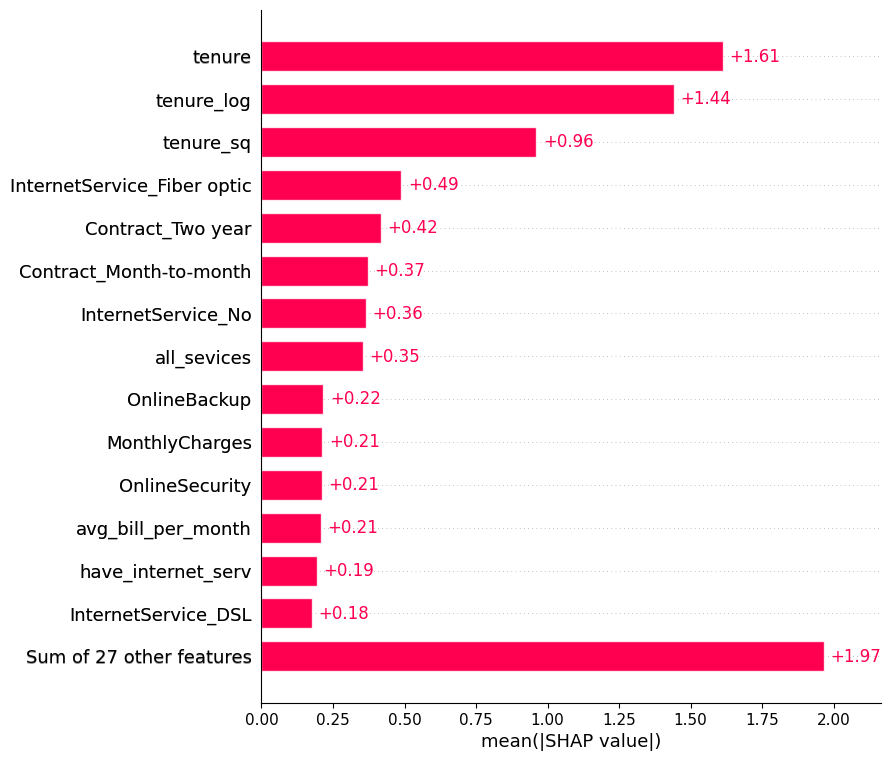

In [97]:
explainer = shap.Explainer(lr_model, X_train)
shap_values = explainer(X_test)
shap.plots.bar(shap_values, max_display=15)

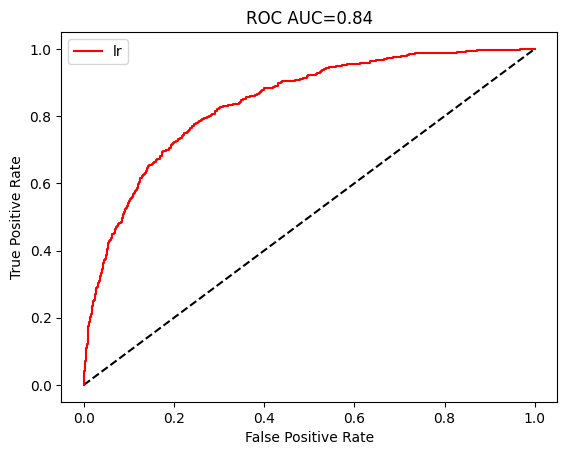

In [105]:
y_pred_prob = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
rocauc_s = roc_auc_score(y_test, y_pred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='lr',color = 'r')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title(f'ROC AUC={rocauc_s:.02}')
plt.show()

In [80]:
gini = 2 * rocauc_s - 1
print(f'gini score: {gini}')

gini score: 0.6829303938254685


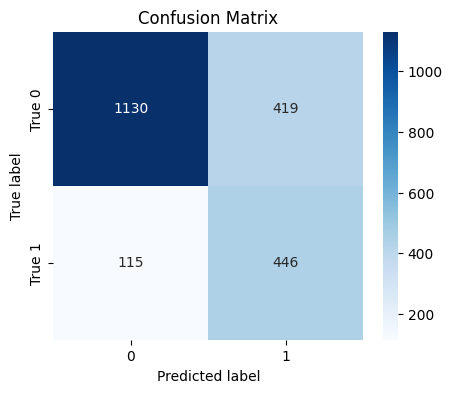

In [ ]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['True 0', 'True 1']
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

Лучшей моделью оказалась логистическая регрессия

После применения SMOTE удалось увеличить Recall класса Churn на 40% по сравнению с baseline'ом

Итоговый F1 score = 0.84

ну и дисбаланс класов сильно влияет на предсказания модели